In [1]:
# import öncesinde terminalde çalıştırılan kodlar:
# env simocuk olarak seçtik.
# conda install -n simocuk pip --force-reinstall -y ,, "simocuk ortamındaki pip'i internetten sıfır ve sağlam haliyle indirip üzerine yaz"
# conda activate simocuk
# /Users/simonxji/anaconda3/envs/simocuk/bin/python -m pip install joblib pandas seaborn matplotlib scikit-learn scikit-uplift catboost lightgbm xgboost

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import missingno as msno
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from catboost import CatBoostClassifier
from sklearn.linear_model import RidgeClassifier
from sklift.models import SoloModel
from sklift.metrics import qini_auc_score
from sklift.metrics import qini_curve, qini_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [2]:
def load_application_train():
    data = pd.read_csv("/Users/simonxji/Desktop/miuul dsb final project/causal-crm-uplift-modeling/hillstrom_kampanya_verisi.csv")
    return data

df = load_application_train()
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.080,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.650,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.830,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.340,1,0,Urban,0,Web,0,Womens E-Mail


In [3]:

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print()
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

def correlation_matrix(df, cols):
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5, annot_kws={'size': 12}, linecolor='w', cmap='RdBu')
    plt.show(block=True)

               treatment  Ratio
treatment                      
Womens E-Mail      21387 33.417
Mens E-Mail        21307 33.292
No E-Mail          21306 33.291



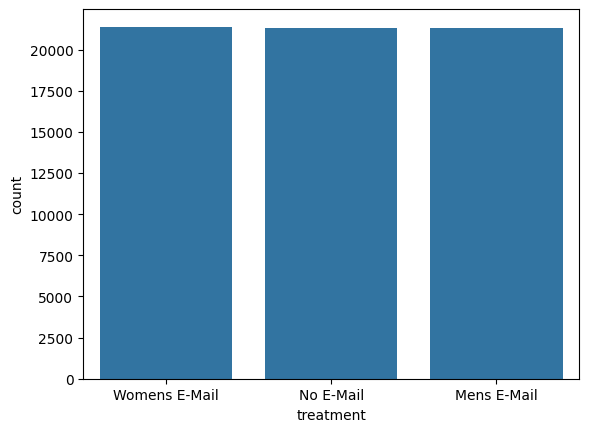

count   64000.000
mean      242.086
std       256.159
min        29.990
5%         29.990
10%        29.990
20%        50.298
30%        80.187
40%       115.280
50%       158.110
60%       210.810
70%       281.210
80%       382.032
90%       561.194
95%       747.262
99%      1218.664
max      3345.930
Name: history, dtype: float64


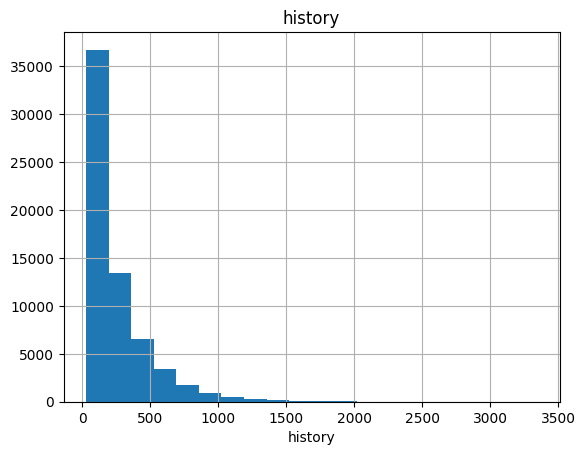

In [4]:
cat_summary(df, "treatment", plot=True)

num_summary(df, "history", plot=True)

In [6]:
target_summary_with_num(df, "target", "history")
target_summary_with_cat(df, "target", "channel") 

        history
target         
0       235.163
1       282.324


              TARGET_MEAN
channel                  
Multichannel        0.172
Phone               0.127
Web                 0.159




In [7]:
df.isnull().values.any()

np.False_

In [8]:
df.head()

# RFM (recency, frequency, monetary (history olarak adlandırılmış))
# history_segment, history'nin gruplanmış hali. sadece birini kullanmak yeterli. ikisi beraber yüksek korelasyon.
# sadece kadın veya sadece erkek ürünü alan kişiler de var. her bir index bir kişiyi temsil eder.
# newbie yeni üye olup olmadığı.
# channel, müşterinin geçmişte alışveriş yaparken hangi kanalı kullandığı
# treatment, müşteriye kadın/erkek emaili mi atıldı ya da hiç email atılmadı mı?
# target, e-posta atıldıktan sonraki 2 hafta içinde bu müşteri siteden alışveriş yaptı mı? tahmin etmeye çalıştığımız değer

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.080,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.650,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.830,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.340,1,0,Urban,0,Web,0,Womens E-Mail


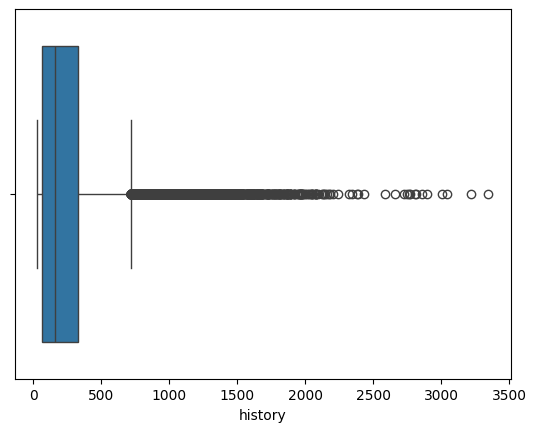

,count,mean,std,min,25%,50%,75%,max
recency,64000.000,5.764,3.508,1.000,2.000,6.000,9.000,12.000
history,64000.000,242.086,256.159,29.990,64.660,158.110,325.657,3345.930
mens,64000.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
womens,64000.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
newbie,64000.000,0.502,0.500,0.000,0.000,1.000,1.000,1.000
target,64000.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


In [9]:
sns.boxplot(x=df["history"])
plt.show() 

df.describe().T
# standart sapmanın ortalamadan büyük olması yüksek varyans yani verinin düzensizliği demektir.

In [10]:

def outlier_thresholds(dataframe, col_name, q1=0.01, q3=0.99):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

check_outlier(df, "history")


True

In [11]:
def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

grab_outliers(df, "history", True) 
# sadece iki müşteri var ama harcamaları aşırı yüksek. bu kişileri direkt silersek değerli bir içgörü kaybolur.
# bunlara Whale denir. Sayıları çok azdır ama şirketin toplam cirosunun çok büyük bir kısmını tek başlarına sırtlarlar. 
# Bu insanların hangi kanalı kullandığı veya e-postalara nasıl tepki verdiği (target) şirket için altın değerindedir.

def replace_with_thresholds(dataframe, variable): # bunun yerine logaritmik dönüşüm de yapılabilir.
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

replace_with_thresholds(df, "history")



       recency history_segment  history  mens  womens   zip_code  newbie       channel  target      treatment
4579         2     7) $1,000 + 3345.930     1       1  Surburban       1         Phone       0      No E-Mail
38680        1     7) $1,000 + 3215.970     1       1      Urban       1  Multichannel       1    Mens E-Mail
43060        1     7) $1,000 + 3003.480     1       1      Urban       1         Phone       0      No E-Mail
52860        1     7) $1,000 + 3040.200     0       1      Urban       1           Web       0  Womens E-Mail


In [12]:
df.describe().T # max history değerimiz az da olsa düştü. çok düşerse gerçekliği yitirir.

,count,mean,std,min,25%,50%,75%,max
recency,64000.000,5.764,3.508,1.000,2.000,6.000,9.000,12.000
history,64000.000,242.076,256.053,29.990,64.660,158.110,325.657,3001.676
mens,64000.000,0.551,0.497,0.000,0.000,1.000,1.000,1.000
womens,64000.000,0.550,0.498,0.000,0.000,1.000,1.000,1.000
newbie,64000.000,0.502,0.500,0.000,0.000,1.000,1.000,1.000
target,64000.000,0.147,0.354,0.000,0.000,0.000,0.000,1.000


target
0   0.853
1   0.147
Name: proportion, dtype: float64


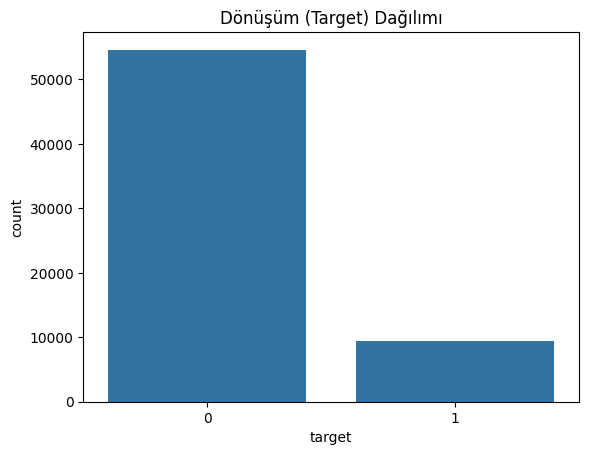

In [13]:
# Satın alma oranlarını yüzdesel olarak görelim
print(df['target'].value_counts(normalize=True))

sns.countplot(data=df, x='target')
plt.title("Dönüşüm (Target) Dağılımı")
plt.show()

In [14]:
# Gruplardaki insan sayıları
print(df['treatment'].value_counts())
print()
# Grupların yüzdesel oranları (A/B testi mantığı gereği %33 - %33 - %33 civarı çıkmalı)
print(df['treatment'].value_counts(normalize=True))

treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

treatment
Womens E-Mail   0.334
Mens E-Mail     0.333
No E-Mail       0.333
Name: proportion, dtype: float64


channel
Multichannel   0.172
Phone          0.127
Web            0.159
Name: target, dtype: float64

zip_code
Rural       0.188
Surburban   0.140
Urban       0.139
Name: target, dtype: float64

            count    mean     std    min    25%     50%     75%      max
history 64000.000 242.076 256.053 29.990 64.660 158.110 325.657 3001.676
recency 64000.000   5.764   3.508  1.000  2.000   6.000   9.000   12.000


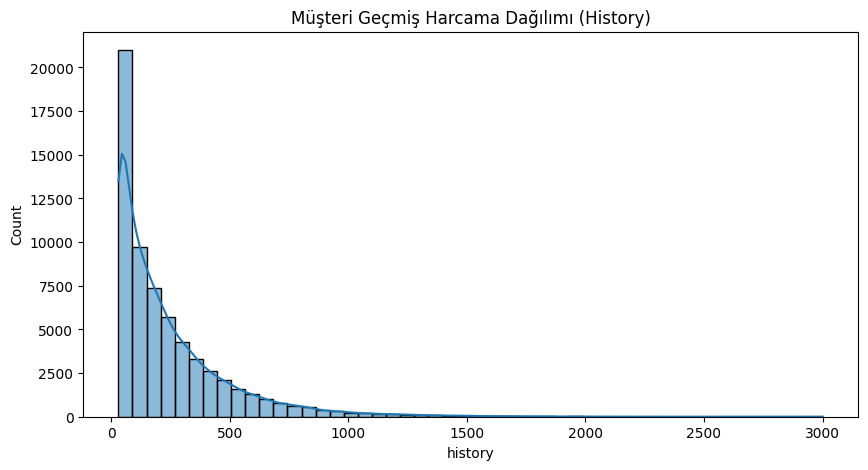

In [15]:
# Hangi alışveriş kanalını kullananların satın alma oranı daha yüksek?
print(df.groupby('channel')['target'].mean())
print()
# Hangi bölgede yaşayanların satın alma oranı daha yüksek?
print(df.groupby('zip_code')['target'].mean())
print()
# Sayısal sütunların genel istatistikleri
print(df[['history', 'recency']].describe().T)

# History sütununun dağılım grafiği - sağa çarpıklığı çıplak gözle göreceksin, yön tayini yapılırken tepe noktasına değil, kuyruğun uzadığı tarafa bakılır.
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='history', kde=True, bins=50)
plt.title("Müşteri Geçmiş Harcama Dağılımı (History)")
plt.show()

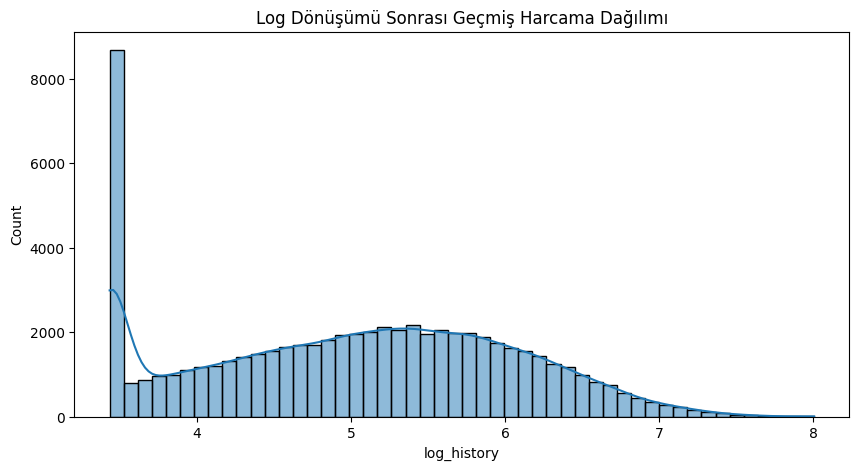

In [16]:
df['log_history'] = np.log1p(df['history']) #right-skewness'ı çözmek için. ridge bundan hoşlanmaz.

# Yeni dağılıma tekrar bakalım
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='log_history', kde=True, bins=50)
plt.title("Log Dönüşümü Sonrası Geçmiş Harcama Dağılımı")
plt.show()


In [17]:
df.drop(columns=['history_segment'], errors='ignore', inplace=True)

In [18]:
df.head()

,recency,history,mens,womens,zip_code,newbie,channel,target,treatment,log_history
0,10,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail,4.966
1,6,329.080,1,1,Rural,1,Web,0,No E-Mail,5.799
2,7,180.650,0,1,Surburban,1,Web,0,Womens E-Mail,5.202
3,9,675.830,1,0,Rural,1,Web,0,Mens E-Mail,6.517
4,2,45.340,1,0,Urban,0,Web,0,Womens E-Mail,3.836


In [19]:
# A. Harcama Yoğunluğu, taze olanın sadakati daha yüksek.
df['spending_intensity'] = df['history'] / (df['recency'] + 1)

# B. Kategori Çeşitliliği, kampanya e-postalarına tepkisi tek bir kategoriye bakan kişiden çok farklı olur.
df['is_unisex_buyer'] = df['mens'] * df['womens']

# C. Dijital Segmentler, kampanyasının etkisini (uplift) hesaplarken eski dijitallerle yeni dijitalleri farklı skorlar vererek ikna etmeye çalışıyor.
df['digital_newbies'] = df['newbie'] * (df['channel'] == 'Web').astype(int)
df['digital_veterans'] = (1 - df['newbie']) * (df['channel'] == 'Web').astype(int)

# D. Şehir merkezinde yaşayıp web kullanan kitle, e-postalara anında reaksiyon göstermeye en müsait olan "hızlı tüketici" segmentidir.
df['urban_web_user'] = ((df['zip_code'] == 'Urban') & (df['channel'] == 'Web')).astype(int)

In [20]:
df.head()

,recency,history,mens,womens,zip_code,newbie,channel,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user
0,10,142.440,1,0,Surburban,0,Phone,0,Womens E-Mail,4.966,12.949,0,0,0,0
1,6,329.080,1,1,Rural,1,Web,0,No E-Mail,5.799,47.011,1,1,0,0
2,7,180.650,0,1,Surburban,1,Web,0,Womens E-Mail,5.202,22.581,0,1,0,0
3,9,675.830,1,0,Rural,1,Web,0,Mens E-Mail,6.517,67.583,0,1,0,0
4,2,45.340,1,0,Urban,0,Web,0,Womens E-Mail,3.836,15.113,0,0,1,1


In [21]:
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first, dtype=int) # drop_first=True, veri setin gereksiz yere şişmez, multicollinearity engeller
    return dataframe

ohe_cols = [col for col in df.columns if (df[col].dtype == 'O' or df[col].dtype.name == 'category') 
            and col not in ['target', 'treatment'] and 10 >= df[col].nunique() > 1]

df = one_hot_encoder(df, ohe_cols) 

# Gördüğün gibi, model ilk 4 kolonun değerini bildiği an, 5. kolonun ne olacağını (oraya bakmasına bile gerek kalmadan) matematiksel olarak %100 doğrulukla bulabilir. İşte bu durum mükemmel çoklu doğrusal bağlantıdır.
# Sen drop_first=False yaptığında, elindeki 5 kolonun toplamı (1) ile Intercept kolonunun kendisi (1) tamamen üst üste biner. Lineer cebirde buna bağımlı matris denir.

In [22]:
df.head()

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.440,1,0,0,0,Womens E-Mail,4.966,12.949,0,0,0,0,1,0,1,0
1,6,329.080,1,1,1,0,No E-Mail,5.799,47.011,1,1,0,0,0,0,0,1
2,7,180.650,0,1,1,0,Womens E-Mail,5.202,22.581,0,1,0,0,1,0,0,1
3,9,675.830,1,0,1,0,Mens E-Mail,6.517,67.583,0,1,0,0,0,0,0,1
4,2,45.340,1,0,0,0,Womens E-Mail,3.836,15.113,0,0,1,1,0,1,0,1


In [23]:
# Odaları tanımlıyoruz 3 odalı sistem, T-Learner (Two/Multi-Learner) Oda 0 (Kontrol), Oda 1 (Kadın), Oda 2 (Erkek)
df['treatment'] = df['treatment'].replace({
    'No E-Mail': 0,
    'Womens E-Mail': 1,
    'Mens E-Mail': 2
})

print("--- 3 Odanın Dağılımı ---")
print(df['treatment'].value_counts())
# Ekranda 3 farklı grup (0, 1 ve 2) dengeli bir şekilde dökülecek!

--- 3 Odanın Dağılımı ---
treatment
1    21387
2    21307
0    21306
Name: count, dtype: int64


/var/folders/l6/z2mgr6l93_j4l97x9l88_sn00000gn/T/ipykernel_33489/1851876320.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['treatment'] = df['treatment'].replace({


In [24]:
df.head(10)

,recency,history,mens,womens,newbie,target,treatment,log_history,spending_intensity,is_unisex_buyer,digital_newbies,digital_veterans,urban_web_user,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,142.440,1,0,0,0,1,4.966,12.949,0,0,0,0,1,0,1,0
1,6,329.080,1,1,1,0,0,5.799,47.011,1,1,0,0,0,0,0,1
2,7,180.650,0,1,1,0,1,5.202,22.581,0,1,0,0,1,0,0,1
3,9,675.830,1,0,1,0,2,6.517,67.583,0,1,0,0,0,0,0,1
4,2,45.340,1,0,0,0,1,3.836,15.113,0,0,1,1,0,1,0,1
5,6,134.830,0,1,0,1,1,4.911,19.261,0,0,0,0,1,0,1,0
6,9,280.200,1,0,1,0,1,5.639,28.020,0,0,0,0,1,0,1,0
7,9,46.420,0,1,0,0,1,3.859,4.642,0,0,0,0,0,1,1,0
8,9,675.070,1,1,1,0,2,6.516,67.507,1,0,0,0,0,0,1,0
9,10,32.840,0,1,1,0,1,3.522,2.985,0,1,0,1,0,1,0,1


In [25]:
df_train, df_test = train_test_split(
    df,
    test_size=0.30,
    random_state=17,
    stratify=df['target'] # Alışveriş oranını iki tarafta da eşit tutar
)


print(f"Eğitim Seti: {df_train.shape}")
print(f"Test Seti: {df_test.shape}")

Eğitim Seti: (44800, 17)
Test Seti: (19200, 17)


In [26]:
num_cols = ['history', 'recency', 'spending_intensity', 'log_history']

scaler = StandardScaler()

# Ortalama ve standart sapmayı sadece Train setinden öğrenip (fit_transform),
# Test setine sadece uyguluyoruz (transform).
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

print(df_train[num_cols].head())

       history  recency  spending_intensity  log_history
36671    0.393   -1.355               1.133        0.816
24599   -0.716   -1.070              -0.418       -0.892
36611   -0.408   -0.500              -0.338       -0.072
179     -0.830   -1.070              -0.518       -1.545
30598   -0.220   -0.785              -0.145        0.219


In [27]:
# ODA 0: Kontrol Grubu (Hiç e-posta almayanlar)
X_train_oda0 = df_train[df_train['treatment'] == 0].drop(columns=['target', 'treatment'])
y_train_oda0 = df_train[df_train['treatment'] == 0]['target']

# ODA 1: Kadın Kampanyası Odası
X_train_oda1 = df_train[df_train['treatment'] == 1].drop(columns=['target', 'treatment'])
y_train_oda1 = df_train[df_train['treatment'] == 1]['target']

# ODA 2: Erkek Kampanyası Odası
X_train_oda2 = df_train[df_train['treatment'] == 2].drop(columns=['target', 'treatment'])
y_train_oda2 = df_train[df_train['treatment'] == 2]['target']

print(f"Oda 0 Müşteri Sayısı: {len(X_train_oda0)}")
print(f"Oda 1 Müşteri Sayısı: {len(X_train_oda1)}")
print(f"Oda 2 Müşteri Sayısı: {len(X_train_oda2)}")

Oda 0 Müşteri Sayısı: 14949
Oda 1 Müşteri Sayısı: 15036
Oda 2 Müşteri Sayısı: 14815


In [29]:
# Odaların içinde arayacağımız örnek parametre setleri (Ağaç derinliği ve öğrenme oranı)
cat_params = {'depth': [4, 6], 'iterations': [100, 150]}
lgb_params = {'max_depth': [4, 6], 'n_estimators': [100, 150]}


# her oda için ayrı ayrı hiperparametre optimizasyonu, oda 0
gs_cat0 = GridSearchCV(CatBoostClassifier(verbose=0, random_state=42), cat_params, cv=5, n_jobs=-1).fit(X_train_oda0, y_train_oda0)
gs_lgb0 = GridSearchCV(LGBMClassifier(verbose=-1, random_state=42), lgb_params, cv=5, n_jobs=-1).fit(X_train_oda0, y_train_oda0)

# oda 1
gs_cat1 = GridSearchCV(CatBoostClassifier(verbose=0, random_state=42), cat_params, cv=5, n_jobs=-1).fit(X_train_oda1, y_train_oda1)
gs_lgb1 = GridSearchCV(LGBMClassifier(verbose=-1, random_state=42), lgb_params, cv=5, n_jobs=-1).fit(X_train_oda1, y_train_oda1)

# oda 2
gs_cat2 = GridSearchCV(CatBoostClassifier(verbose=0, random_state=42), cat_params, cv=5, n_jobs=-1).fit(X_train_oda2, y_train_oda2)
gs_lgb2 = GridSearchCV(LGBMClassifier(verbose=-1, random_state=42), lgb_params, cv=5, n_jobs=-1).fit(X_train_oda2, y_train_oda2)

print("oda 1 en iyi CatBoost parametreleri:", gs_cat1.best_params_)

oda 1 en iyi CatBoost parametreleri: {'depth': 4, 'iterations': 150}


In [30]:
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# her oda için üçlü ensemble
best_cat0 = CatBoostClassifier(**gs_cat0.best_params_, verbose=0, random_state=42).fit(X_train_oda0, y_train_oda0)
best_lgb0 = LGBMClassifier(**gs_lgb0.best_params_, verbose=-1, random_state=42).fit(X_train_oda0, y_train_oda0)
best_ridge0 = LogisticRegression(penalty='l2', max_iter=1000, random_state=42).fit(X_train_oda0, y_train_oda0)


best_cat1 = CatBoostClassifier(**gs_cat1.best_params_, verbose=0, random_state=42).fit(X_train_oda1, y_train_oda1)
best_lgb1 = LGBMClassifier(**gs_lgb1.best_params_, verbose=-1, random_state=42).fit(X_train_oda1, y_train_oda1)
best_ridge1 = LogisticRegression(penalty='l2', max_iter=1000, random_state=42).fit(X_train_oda1, y_train_oda1)

best_cat2 = CatBoostClassifier(**gs_cat2.best_params_, verbose=0, random_state=42).fit(X_train_oda2, y_train_oda2)
best_lgb2 = LGBMClassifier(**gs_lgb2.best_params_, verbose=-1, random_state=42).fit(X_train_oda2, y_train_oda2)
best_ridge2 = LogisticRegression(penalty='l2', max_iter=1000, random_state=42).fit(X_train_oda2, y_train_oda2)


/Users/simonxji/anaconda3/envs/simocuk/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/simonxji/anaconda3/envs/simocuk/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/simonxji/anaconda3/envs/simocuk/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in versi

/Users/simonxji/anaconda3/envs/simocuk/lib/python3.14/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


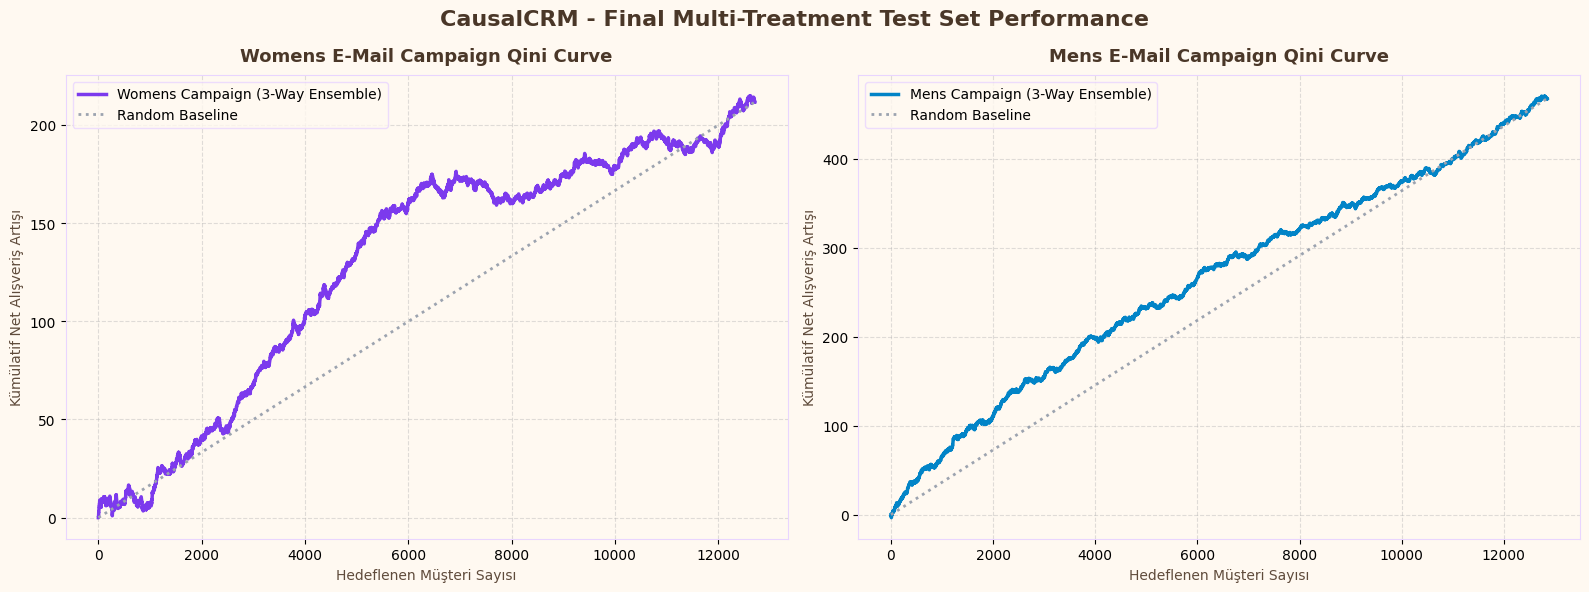

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklift.metrics import qini_curve

# test setinin özellikleri
X_test = df_test.drop(columns=['target', 'treatment'])

# CatBoost (%50), LightGBM (%30), Ridge (%20)
def predict_hybrid(model_cat, model_lgb, model_ridge, data):
    pred_cat = model_cat.predict_proba(data)[:, 1]
    pred_lgb = model_lgb.predict_proba(data)[:, 1]
    pred_ridge = model_ridge.predict_proba(data)[:, 1]
    return (0.5 * pred_cat) + (0.3 * pred_lgb) + (0.2 * pred_ridge)

# her test satırı için 3 odadan da olasılık puanlarını topluyoruz
p_oda0 = predict_hybrid(best_cat0, best_lgb0, best_ridge0, X_test) # Mail almazsa
p_oda1 = predict_hybrid(best_cat1, best_lgb1, best_ridge1, X_test) # Kadın maili alırsa
p_oda2 = predict_hybrid(best_cat2, best_lgb2, best_ridge2, X_test) # Erkek maili alırsa

# 4. SAF UPLIFT SKORLARININ HESAPLANMASI
uplift_kadin = p_oda1 - p_oda0
uplift_erkek = p_oda2 - p_oda0

# 5. MATEMATİKSEL KAZANÇ (QINI) KOORDİNATLARI (Sadece x ve y olarak 2 değer unpack ediyoruz)
mask_kadin = (df_test['treatment'] == 0) | (df_test['treatment'] == 1)
x_k, y_k = qini_curve(y_true=df_test[mask_kadin]['target'], uplift=uplift_kadin[mask_kadin], treatment=df_test[mask_kadin]['treatment'])

treat_test_erkek_binary = np.where(df_test['treatment'] == 2, 1, 0)
mask_erkek = (df_test['treatment'] == 0) | (df_test['treatment'] == 2)
x_e, y_e = qini_curve(y_true=df_test[mask_erkek]['target'], uplift=uplift_erkek[mask_erkek], treatment=treat_test_erkek_binary[mask_erkek])



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='#FFF9F1')
ax1.set_facecolor('#FFF9F1')
ax2.set_facecolor('#FFF9F1')

# kadın kampanyası QİN
ax1.plot(x_k, y_k, label='Womens Campaign (3-Way Ensemble)', color='#7C3AED', linewidth=2.5)
# Rastgele Baseline: (0,0) noktasından başlar, modelin bittiği (x_son, y_son) noktasına düz çizgi çeker
ax1.plot([0, x_k[-1]], [0, y_k[-1]], color='#9CA3AF', linestyle=':', linewidth=2, label='Random Baseline')

ax1.set_title('Womens E-Mail Campaign Qini Curve', fontsize=13, fontweight='bold', color='#4A3728', pad=10)
ax1.set_xlabel('Hedeflenen Müşteri Sayısı', color='#5F4B3B')
ax1.set_ylabel('Kümülatif Net Alışveriş Artışı', color='#5F4B3B')
ax1.legend(facecolor='#FFF9F1', edgecolor='#E9D5FF')
ax1.grid(True, linestyle='--', alpha=0.4)

# erkek kampanyası QİN
ax2.plot(x_e, y_e, label='Mens Campaign (3-Way Ensemble)', color='#0284C7', linewidth=2.5) # Canlı Mavi
# Rastgele Baseline
ax2.plot([0, x_e[-1]], [0, y_e[-1]], color='#9CA3AF', linestyle=':', linewidth=2, label='Random Baseline')

ax2.set_title('Mens E-Mail Campaign Qini Curve', fontsize=13, fontweight='bold', color='#4A3728', pad=10)
ax2.set_xlabel('Hedeflenen Müşteri Sayısı', color='#5F4B3B')
ax2.set_ylabel('Kümülatif Net Alışveriş Artışı', color='#5F4B3B')
ax2.legend(facecolor='#FFF9F1', edgecolor='#E9D5FF')
ax2.grid(True, linestyle='--', alpha=0.4)


for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color('#E9D5FF')

plt.suptitle('CausalCRM - Final Multi-Treatment Test Set Performance', fontsize=16, fontweight='bold', color='#4A3728', y=0.98)
plt.tight_layout()
plt.show()

In [32]:
# 1. Hiç mail atılmayan Kontrol Grubunun kendi kendine organik alışveriş yapma oranı (Sure Things)
organik_oran = df[df['treatment'] == 0]['target'].mean()

# 2. Toplam gönderilen kadın ve erkek e-postası sayısı
toplam_mail_atilan = len(df[df['treatment'] != 0])

# 3. Şirketin ZATEN ALACAK OLANLARA attığı boşuna mail sayısı
bosa_giden_hedef = toplam_mail_atilan * organik_oran

print(f"Toplam Mail Atılan Kişi: {toplam_mail_atilan}")
print(f"Zaten Alacak Olanların Oranı (Sure Things): %{round(organik_oran*100, 2)}")
print(f"Şirketin BOŞUNA KAMPANYA YAPTIĞI Müşteri Sayısı: {int(bosa_giden_hedef)}")

Toplam Mail Atılan Kişi: 42694
Zaten Alacak Olanların Oranı (Sure Things): %10.62
Şirketin BOŞUNA KAMPANYA YAPTIĞI Müşteri Sayısı: 4532


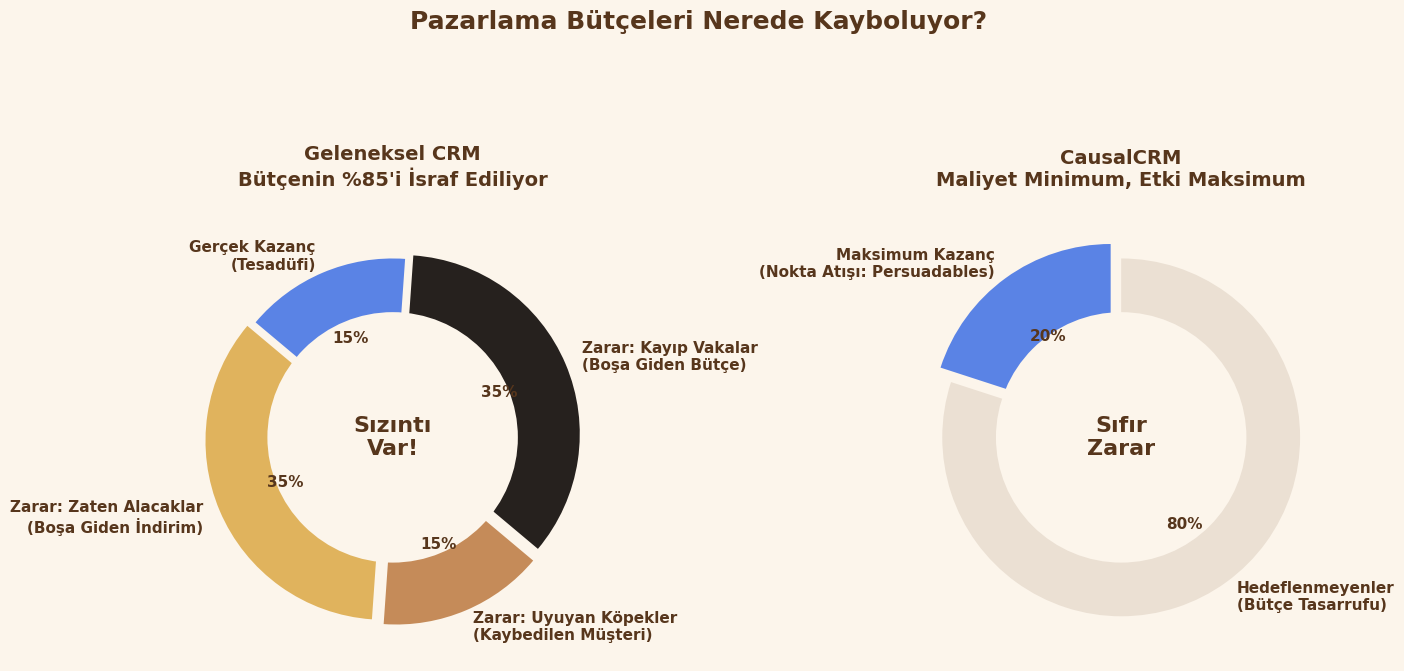

In [ ]:
import matplotlib.pyplot as plt

bg_color = '#FCF5EB'       
text_color = '#57361C'     
terracotta = '#C58B59'     
mustard = '#E0B35D'        
soft_black = '#26211E'     
saved_bg = '#EBE0D3'       

# Yeşili iptal edip, alttaki dalgayla uyumlu o tatlı maviyi ekliyoruz
soft_blue = '#5A83E5'      

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), facecolor=bg_color)

# geleneksel CRM grafiği
labels_trad = ['Zarar: Zaten Alacaklar\n(Boşa Giden İndirim)', 
               'Zarar: Uyuyan Köpekler\n(Kaybedilen Müşteri)', 
               'Zarar: Kayıp Vakalar\n(Boşa Giden Bütçe)', 
               'Gerçek Kazanç\n(Tesadüfi)']
sizes_trad = [35, 15, 35, 15] 


colors_trad = [mustard, terracotta, soft_black, soft_blue]
explode_trad = (0.05, 0.05, 0.05, 0)

wedges1, texts1, autotexts1 = ax1.pie(
    sizes_trad, explode=explode_trad, labels=labels_trad, colors=colors_trad, 
    autopct='%1.0f%%', startangle=140, 
    textprops=dict(fontsize=11, fontweight='bold')
)

for text in texts1 + autotexts1:
    text.set_color(text_color)

centre_circle1 = plt.Circle((0,0), 0.70, fc=bg_color)
ax1.add_patch(centre_circle1)

ax1.set_title('Geleneksel CRM\nBütçenin %85\'i İsraf Ediliyor', color=text_color, fontsize=14, fontweight='bold', pad=20)
ax1.text(0, 0, 'Sızıntı\nVar!', ha='center', va='center', fontsize=16, fontweight='bold', color=text_color)


# causal CRM grafiği
labels_causal = ['Maksimum Kazanç\n(Nokta Atışı: Persuadables)', 'Hedeflenmeyenler\n(Bütçe Tasarrufu)']
sizes_causal = [20, 80] 

colors_causal = [soft_blue, saved_bg]
explode_causal = (0.1, 0)

wedges2, texts2, autotexts2 = ax2.pie(
    sizes_causal, explode=explode_causal, labels=labels_causal, colors=colors_causal, 
    autopct='%1.0f%%', startangle=90, 
    textprops=dict(fontsize=11, fontweight='bold')
)

for text in texts2 + autotexts2:
    text.set_color(text_color)

centre_circle2 = plt.Circle((0,0), 0.70, fc=bg_color)
ax2.add_patch(centre_circle2)

ax2.set_title('CausalCRM\nMaliyet Minimum, Etki Maksimum', color=text_color, fontsize=14, fontweight='bold', pad=20)
ax2.text(0, 0, 'Sıfır\nZarar', ha='center', va='center', fontsize=16, fontweight='bold', color=text_color)

plt.suptitle('Pazarlama Bütçeleri Nerede Kayboluyor?', fontsize=18, fontweight='bold', color=text_color, y=1.05)
plt.tight_layout()
plt.show()

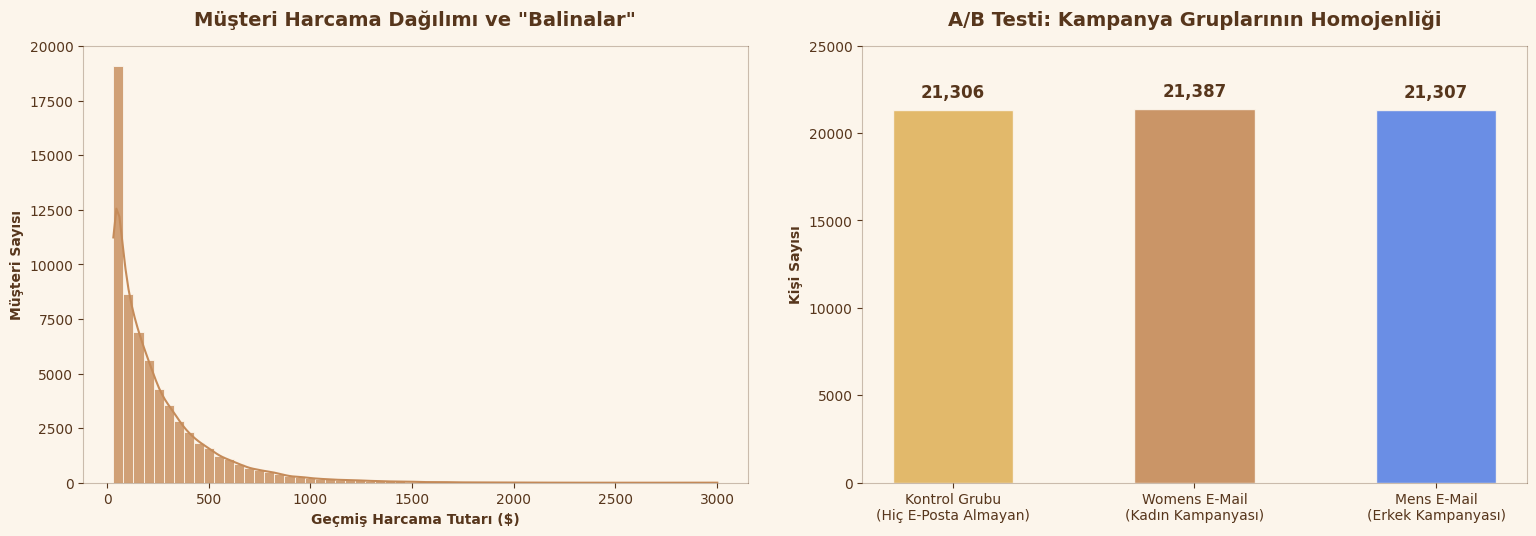

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


bg_color = '#FCF5EB'      
text_color = '#57361C'     
terracotta = '#C58B59'    
mustard = '#E0B35D'        
soft_blue = '#5A83E5'      

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor=bg_color)


sns.histplot(data=df, x='history', bins=60, kde=True, color=terracotta, ax=ax1, edgecolor=bg_color, alpha=0.8)

ax1.set_facecolor(bg_color)
ax1.set_title('Müşteri Harcama Dağılımı ve "Balinalar"', color=text_color, fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Geçmiş Harcama Tutarı ($)', color=text_color, fontweight='bold')
ax1.set_ylabel('Müşteri Sayısı', color=text_color, fontweight='bold')
ax1.tick_params(colors=text_color)

for spine in ax1.spines.values():
    spine.set_color(text_color)
    spine.set_alpha(0.3)


gruplar = ['Kontrol Grubu\n(Hiç E-Posta Almayan)', 'Womens E-Mail\n(Kadın Kampanyası)', 'Mens E-Mail\n(Erkek Kampanyası)']
sayilar = [21306, 21387, 21307]
renkler = [mustard, terracotta, soft_blue]

bars = ax2.bar(gruplar, sayilar, color=renkler, edgecolor=bg_color, width=0.5, alpha=0.9)

ax2.set_facecolor(bg_color)
ax2.set_title('A/B Testi: Kampanya Gruplarının Homojenliği', color=text_color, fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Kişi Sayısı', color=text_color, fontweight='bold')
ax2.tick_params(colors=text_color)
ax2.set_ylim(0, 25000) # barların üstündeki boşluk

for spine in ax2.spines.values():
    spine.set_color(text_color)
    spine.set_alpha(0.3)

# barların tam üstüne sayıları yazdırıyoruz
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 500, f"{int(yval):,}", 
             ha='center', va='bottom', color=text_color, fontweight='bold', fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()